In [1]:
import matplotlib.pyplot as plt
import polars as pl

plt.style.use("ggplot")

In [2]:
df = pl.read_csv("../data/4/BradleyDoublePlusGoodMeltingPointDataset.csv")
df.head(10)

key,name,smiles,mpC,csid,link,source,count,min,max,range
i64,str,str,f64,i64,str,str,i64,f64,f64,f64
27956,"""cyclobutylmethane""","""C1(CCC1)C""",-161.51,11232,"""http://pubs.acs.org/doi/abs/10…","""Lemaire HP; Livingston RL Jour…",2,-161.51,-161.5,0.01
16005,"""Nitrogen oxide""","""[O-][N+]#N""",-90.8,923,"""http://msds.chem.ox.ac.uk/""","""academic website""",2,-90.81,-90.8,0.01
16127,"""Sulfuryl difluoride""","""FS(F)(=O)=O""",-135.8,16647,"""http://msds.chem.ox.ac.uk/""","""academic website""",2,-135.82,-135.8,0.02
17138,"""disopyramide""","""CC(C)N(CCC(c1ccccn1)(c2ccccc2)…",94.8,3002,"""http://dx.doi.org/10.1021/ci70…","""Hughes LD; Palmer DS; Nigsch F…",2,94.75,94.8,0.05
15628,"""Bromine""","""BrBr""",-7.2,22817,"""http://msds.chem.ox.ac.uk/""","""academic website""",2,-7.25,-7.2,0.05
16624,"""Lomefloxacin""","""O=C(O)C2=CN(CC)c1c(F)c(c(F)cc1…",239.75,3811,"""http://www.drugbank.ca/drugs/D…","""DrugBank""",3,239.75,239.8,0.05
15962,"""N,N-Dimethylmethanamine""","""CN(C)C""",-117.0,1114,"""http://msds.chem.ox.ac.uk/""","""academic website""",2,-117.08,-117.0,0.08
16135,"""Tetrachloromethane""","""ClC(Cl)(Cl)Cl""",-23.0,5730,"""http://msds.chem.ox.ac.uk/""","""academic website""",8,-23.0,-22.92,0.08
15862,"""Iodine""","""II""",113.5,785,"""http://msds.chem.ox.ac.uk/""","""academic website""",2,113.5,113.6,0.1


In [3]:
df.height

3041

In [4]:
df["name"].n_unique()

3040

In [5]:
df["smiles"].n_unique()

3041

In [6]:
df.filter(df["name"].is_duplicated())

key,name,smiles,mpC,csid,link,source,count,min,max,range
i64,str,str,f64,i64,str,str,i64,f64,f64,f64
8831,"""griseofulvin""","""COC1=CC(=O)CC(C)C13Oc2c(Cl)c(O…",219.0,3392,"""http://dx.doi.org/10.1021/ci02…","""Bergstrom C. A. S.; Norinder U…",3,219.0,220.0,1.0
7275,"""griseofulvin""","""C[C@@H]1CC(=O)C=C([C@]12C(=O)c…",219.0,389934,"""http://www.alfa.com/en/GP100W.…","""Alfa Aesar""",3,219.0,220.0,1.0


In [7]:
df = df.remove(pl.col("csid") == 389934)
df.height

3040

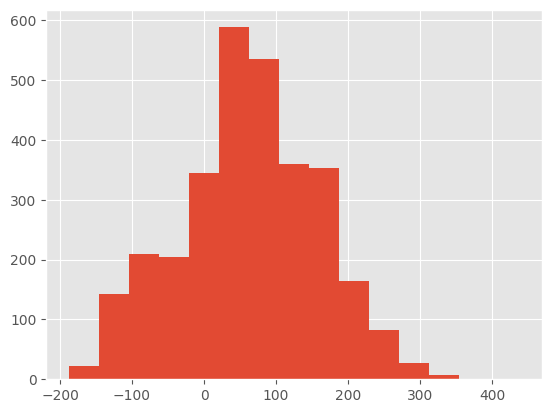

In [8]:
plt.hist(
    df["mpC"],
    bins=15,
);

In [9]:
df.select(["name", "smiles", "mpC"]).write_parquet("../data/processed/deduplicated.parquet")